<a href="https://www.kaggle.com/code/aamir28/titanic-30-day-competition-notebook?scriptVersionId=337079860" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 🚢 Titanic — 30-Day Kaggle ML Study Notebook

A complete 30-day journey through the Titanic competition, adding one new ML technique per day.
All CV scores shown are **real results** from 5-fold StratifiedKFold on the training set.

| Phase | Days | Focus |
|-------|------|-------|
| **Foundation** | 1–7 | Preprocessing, feature engineering |
| **Model Zoo** | 8–14 | Hyperparameter tuning, diverse algorithms |
| **Advanced Features** | 15–20 | Imputation, polynomials, neural nets, interactions |
| **Ensembles** | 21–28 | Boosting, stacking, weighted voting |
| **Final Polish** | 29–30 | Extensive tuning, best submission |

**Best CV accuracy achieved: 84.40% (Day 29–30)**

> 📁 Place `train.csv` and `test.csv` in the same folder as this notebook before running.

## 🔧 Setup — Installs & Imports

In [1]:
import subprocess, sys
for pkg in ['xgboost','lightgbm','catboost']:
    subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])
print('All packages ready')

All packages ready


In [2]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               VotingClassifier, StackingClassifier, AdaBoostClassifier,
                               RandomForestRegressor)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import SelectFromModel
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

sns.set_theme(style='whitegrid', palette='muted')
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Helpers used throughout
DECK_MAP = {'A':0,'B':1,'C':2,'D':3,'E':4,'F':5,'G':6,'T':7,'U':8}
BASE_FEATS  = ['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']
ALL_FEATS   = BASE_FEATS + ['FamilySize','IsAlone','Title','AgeGroup',
                             'FarePerPerson','CabinKnown','Deck','Sex_Age','Sex_Pclass']
SEL_FEATS   = ['Sex','Age','Fare','Title','FarePerPerson','Sex_Age','Sex_Pclass']
KEEP27      = ['Pclass','Sex','Age','SibSp','Fare','Embarked','FamilySize',
               'Title','AgeGroup','FarePerPerson','Deck','Sex_Age','Sex_Pclass']
RF8_PARAMS  = {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
XGB9_PARAMS = {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
XGB29_PARAMS= {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}

def mk_rf():  return RandomForestClassifier(**RF8_PARAMS, random_state=42)
def mk_xgb(): return XGBClassifier(**XGB9_PARAMS, eval_metric='logloss', verbosity=0, random_state=42)
def mk_lr():  return Pipeline([('sc',StandardScaler()),('lr',LogisticRegression(max_iter=1000,random_state=42))])
def mk_gbm(): return GradientBoostingClassifier(n_estimators=100, random_state=42)

print('Imports OK ✓')

Imports OK ✓


## 📦 Load Data & EDA

In [3]:
train_raw = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test_raw  = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')
print(f'Train: {train_raw.shape}  |  Test: {test_raw.shape}')
train_raw.head()

Train: (891, 12)  |  Test: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


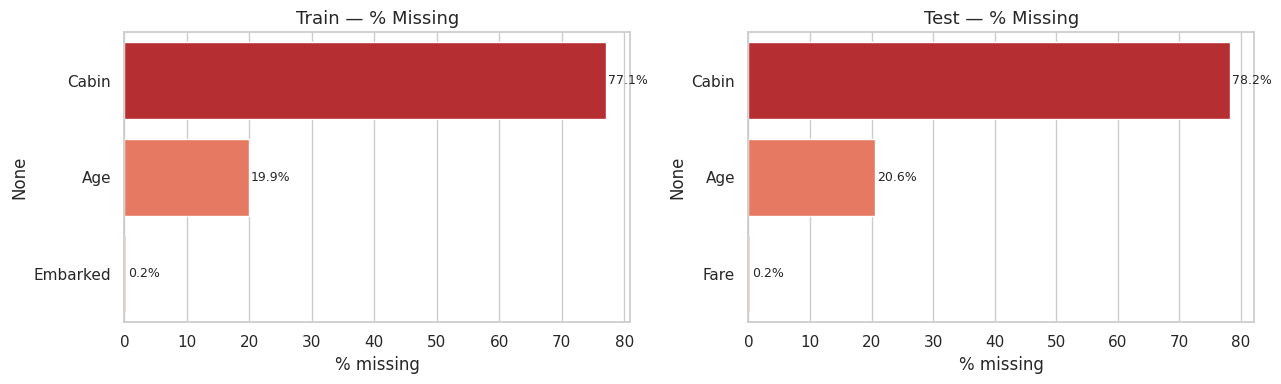

In [4]:
# Missing value heatmap
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, df, title in zip(axes, [train_raw, test_raw], ['Train', 'Test']):
    miss = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    miss = miss[miss > 0]
    sns.barplot(x=miss.values, y=miss.index, ax=ax, palette='Reds_r')
    ax.set_title(f'{title} — % Missing', fontsize=13)
    ax.set_xlabel('% missing')
    for i, v in enumerate(miss.values):
        ax.text(v+0.3, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout(); plt.show()

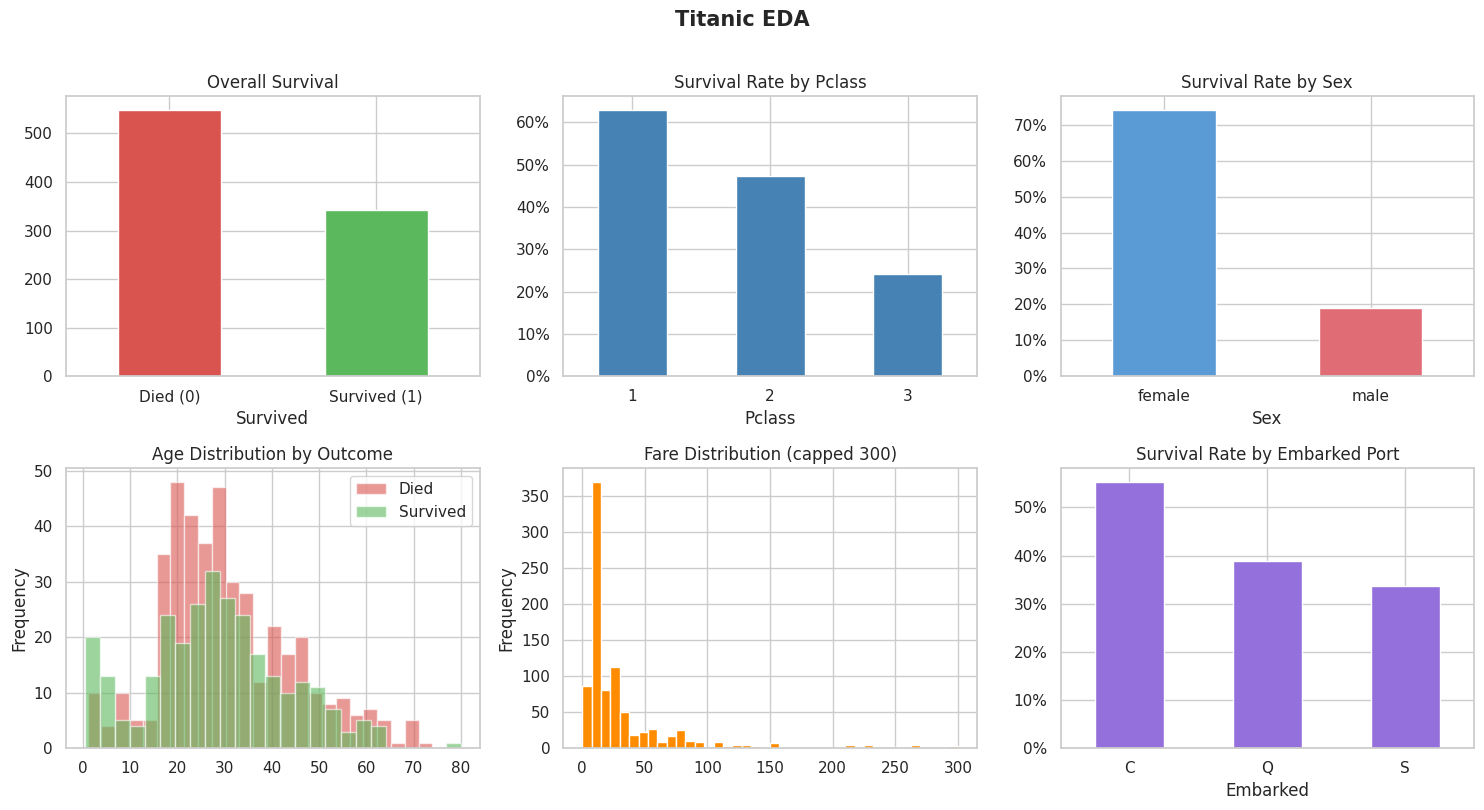

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
train_raw['Survived'].value_counts().plot.bar(ax=axes[0,0],
    color=['#d9534f','#5cb85c'], rot=0, title='Overall Survival')
axes[0,0].set_xticklabels(['Died (0)','Survived (1)'])

train_raw.groupby('Pclass')['Survived'].mean().plot.bar(ax=axes[0,1],
    color='steelblue', rot=0, title='Survival Rate by Pclass')
axes[0,1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

train_raw.groupby('Sex')['Survived'].mean().plot.bar(ax=axes[0,2],
    color=['#5b9bd5','#e06c75'], rot=0, title='Survival Rate by Sex')
axes[0,2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for survived, color, label in [(0,'#d9534f','Died'),(1,'#5cb85c','Survived')]:
    train_raw[train_raw['Survived']==survived]['Age'].dropna().plot.hist(
        ax=axes[1,0], bins=25, alpha=0.6, color=color, label=label, edgecolor='white')
axes[1,0].set_title('Age Distribution by Outcome'); axes[1,0].legend()

train_raw['Fare'].clip(upper=300).plot.hist(ax=axes[1,1], bins=40,
    color='darkorange', edgecolor='white', title='Fare Distribution (capped 300)')

train_raw.groupby('Embarked')['Survived'].mean().plot.bar(ax=axes[1,2],
    color='mediumpurple', rot=0, title='Survival Rate by Embarked Port')
axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.suptitle('Titanic EDA', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

## 🛠 Shared Preprocessing & Helpers
Run this cell once — every Day cell calls `preprocess()` and `evaluate()`.

In [6]:
def preprocess(train_raw, test_raw):
    """Full feature engineering pipeline. Returns (X, y, X_test)."""
    train = train_raw.copy(); test = test_raw.copy()
    age_med = train['Age'].median(); fare_med = train['Fare'].median()
    for df in [train, test]:
        # Basic imputation
        df['Age']      = df['Age'].fillna(age_med)
        df['Fare']     = df['Fare'].fillna(fare_med)
        df['Embarked'] = df['Embarked'].fillna('S')
        # Encode categoricals
        df['Sex']      = df['Sex'].map({'male':0,'female':1})
        df['Embarked'] = df['Embarked'].map({'S':0,'C':1,'Q':2})
        # Family features
        df['FamilySize'] = df['SibSp'] + df['Parch']
        df['IsAlone']    = (df['FamilySize'] == 0).astype(int)
        # Title extraction
        t = df['Name'].str.extract(r',\s*([^\.]+)\.', expand=False).str.strip()
        rare_m = {'Dr','Rev','Col','Major','Capt','Jonkheer','Don','Sir'}
        rare_f = {'Lady','Mme','Ms','Mlle','the Countess','Dona'}
        title_map = {'Mr':0,'Miss':1,'Mrs':2,'Master':3,'Rare_Male':4,'Rare_Female':5}
        df['Title'] = t.apply(lambda x: 'Rare_Male' if x in rare_m
                               else ('Rare_Female' if x in rare_f else x))
        df['Title'] = df['Title'].map(title_map).fillna(4).astype(int)
        # Age groups
        df['AgeGroup'] = pd.cut(df['Age'], bins=[0,12,25,60,100],
                                 labels=[0,1,2,3]).astype(int)
        # Fare per person
        df['FarePerPerson'] = df['Fare'] / (df['FamilySize'] + 1)
        # Cabin features
        df['CabinKnown'] = df['Cabin'].notna().astype(int)
        df['Deck'] = (df['Cabin'].str[0].fillna('U')
                      .map(DECK_MAP).fillna(8).astype(int))
        # Interaction features
        df['Sex_Age']    = df['Sex'] * df['Age']
        df['Sex_Pclass'] = df['Sex'] * df['Pclass']
    X    = train[ALL_FEATS].copy()
    y    = train['Survived']
    X_te = test[ALL_FEATS].copy()
    return X, y, X_te

def evaluate(model, X, y, label=''):
    """5-fold CV accuracy with formatted output."""
    s = cross_val_score(model, X, y, cv=CV, scoring='accuracy')
    print(f'{label:45s}  CV: {s.mean():.4f} ± {s.std():.4f}')
    return round(s.mean(), 4)

def save_submission(model, X_train, y_train, X_test, test_raw, day):
    """Fit model, predict, and save submission CSV."""
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    fname = f'submission_day{day:02d}.csv'
    pd.DataFrame({'PassengerId': test_raw['PassengerId'],
                  'Survived': preds}).to_csv(fname, index=False)
    print(f'Saved {fname}  (survival rate: {preds.mean():.3f})')
    return fname

# Pre-load data for all Day cells
X, y, X_te = preprocess(train_raw, test_raw)
print(f'Ready — X: {X.shape}, features: {ALL_FEATS}')

Ready — X: (891, 16), features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title', 'AgeGroup', 'FarePerPerson', 'CabinKnown', 'Deck', 'Sex_Age', 'Sex_Pclass']


## Day 01 — Baseline Random Forest
> **CV Accuracy: 0.8182**

Simplest possible model: `RandomForestClassifier(n_estimators=100)` on 7 core numeric features. This is our performance floor — every future day should beat or match it.

Day 01 · RF Baseline                           CV: 0.8182 ± 0.0249


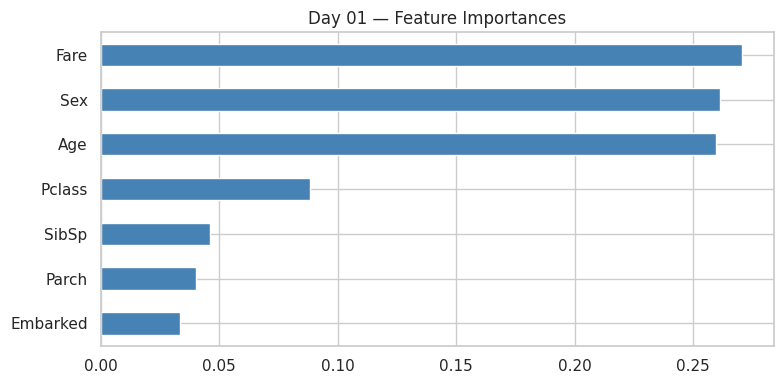

Saved submission_day01.csv  (survival rate: 0.359)


'submission_day01.csv'

In [7]:
X1 = X[BASE_FEATS]
model_d1 = RandomForestClassifier(n_estimators=100, random_state=42)
score_d1 = evaluate(model_d1, X1, y, 'Day 01 · RF Baseline')

# Feature importances
model_d1.fit(X1, y)
fi = pd.Series(model_d1.feature_importances_, index=BASE_FEATS).sort_values(ascending=True)
fi.plot.barh(figsize=(8,4), color='steelblue', title='Day 01 — Feature Importances')
plt.tight_layout(); plt.show()

save_submission(RandomForestClassifier(n_estimators=100,random_state=42),
                X1, y, X_te[BASE_FEATS], test_raw, 1)

## Day 02 — FamilySize & IsAlone
> **CV Accuracy: 0.8204**

`FamilySize = SibSp + Parch`. `IsAlone = 1` for solo travellers.

**Key insight:** Small families (2–4) had ~55–72% survival; solo travellers only 30%, large families <15%.

Day 02 · RF + FamilySize/IsAlone               CV: 0.8204 ± 0.0206


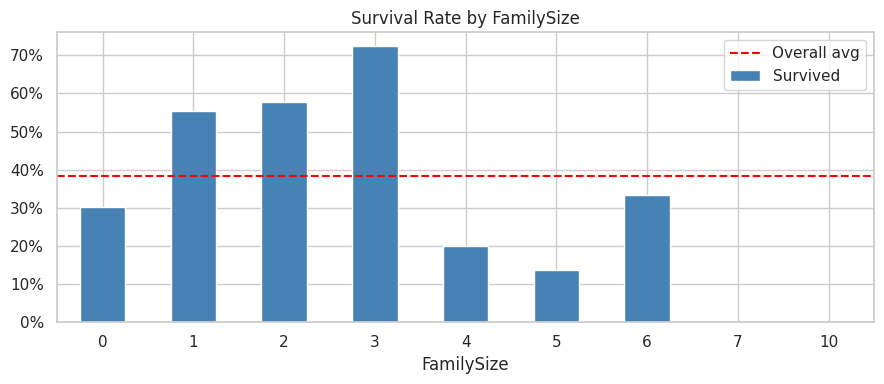

Saved submission_day02.csv  (survival rate: 0.368)


'submission_day02.csv'

In [8]:
X2 = X[BASE_FEATS + ['FamilySize','IsAlone']]
score_d2 = evaluate(RandomForestClassifier(100,random_state=42), X2, y, 'Day 02 · RF + FamilySize/IsAlone')

# Survival by family size chart
tmp = train_raw.copy()
tmp['FamilySize'] = tmp['SibSp'] + tmp['Parch']
ax = tmp.groupby('FamilySize')['Survived'].mean().plot.bar(
    figsize=(9,4), color='steelblue', rot=0, title='Survival Rate by FamilySize')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.axhline(train_raw['Survived'].mean(), color='red', linestyle='--', label='Overall avg')
ax.legend(); plt.tight_layout(); plt.show()

save_submission(RandomForestClassifier(100,random_state=42), X2, y, X_te[X2.columns], test_raw, 2)

## Day 03 — Title Extraction from Name
> **CV Accuracy: 0.8204**

Regex-extract the social title (Mr, Mrs, Miss, Master…) from the `Name` field. Consolidate 18 raw titles into 6 groups. **Title** encodes both gender and age simultaneously — it becomes one of the most important features from here on.

Day 03 · RF + Title                            CV: 0.8204 ± 0.0181


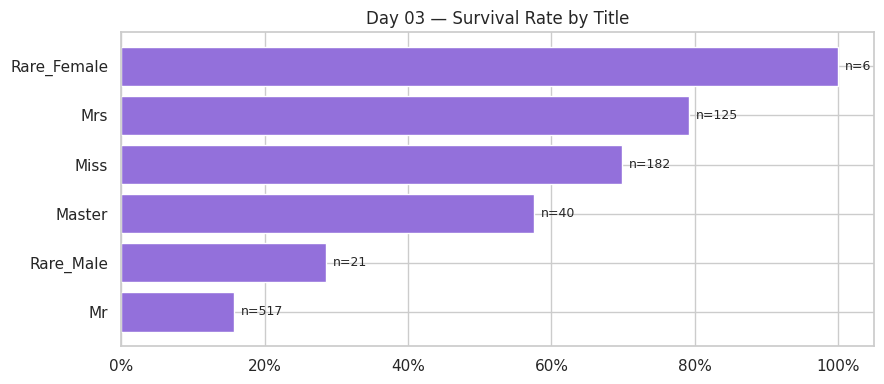

Saved submission_day03.csv  (survival rate: 0.378)


'submission_day03.csv'

In [9]:
X3 = X[BASE_FEATS + ['FamilySize','IsAlone','Title']]
score_d3 = evaluate(RandomForestClassifier(100,random_state=42), X3, y, 'Day 03 · RF + Title')

# Survival by title
tmp = train_raw.copy()
t = tmp['Name'].str.extract(r',\s*([^\.]+)\.', expand=False).str.strip()
rare_m = {'Dr','Rev','Col','Major','Capt','Jonkheer','Don','Sir'}
rare_f = {'Lady','Mme','Ms','Mlle','the Countess','Dona'}
tmp['Title'] = t.apply(lambda x: 'Rare_Male' if x in rare_m
                        else ('Rare_Female' if x in rare_f else x))
grp = tmp.groupby('Title')['Survived'].agg(['mean','count']).sort_values('mean')
fig, ax = plt.subplots(figsize=(9,4))
bars = ax.barh(grp.index, grp['mean'], color='mediumpurple')
for bar, cnt in zip(bars, grp['count']):
    ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
            f'n={cnt}', va='center', fontsize=9)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Day 03 — Survival Rate by Title'); plt.tight_layout(); plt.show()

save_submission(RandomForestClassifier(100,random_state=42), X3, y, X_te[X3.columns], test_raw, 3)

## Day 04 — Logistic Regression + Feature Scaling
> **CV Accuracy: 0.8126**

Logistic Regression needs `StandardScaler` — without it, Fare (0–512) swamps IsAlone (0–1). Wrapped in a sklearn `Pipeline`. Coefficients are directly interpretable after scaling.

Day 04 · Logistic Regression (scaled)          CV: 0.8126 ± 0.0168


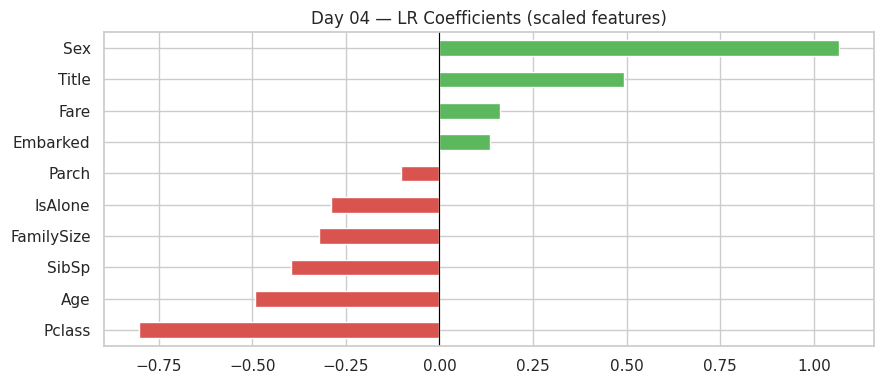

Saved submission_day04.csv  (survival rate: 0.383)


'submission_day04.csv'

In [10]:
X4 = X[BASE_FEATS + ['FamilySize','IsAlone','Title']]
pipe_d4 = Pipeline([('sc',StandardScaler()),
                    ('lr',LogisticRegression(max_iter=1000, random_state=42))])
score_d4 = evaluate(pipe_d4, X4, y, 'Day 04 · Logistic Regression (scaled)')

pipe_d4.fit(X4, y)
coefs = pd.Series(pipe_d4.named_steps['lr'].coef_[0], index=X4.columns).sort_values()
colors = ['#d9534f' if v < 0 else '#5cb85c' for v in coefs]
coefs.plot.barh(figsize=(9,4), color=colors, title='Day 04 — LR Coefficients (scaled features)')
plt.axvline(0, color='black', lw=0.8); plt.tight_layout(); plt.show()

save_submission(pipe_d4, X4, y, X_te[X4.columns], test_raw, 4)

## Day 05 — XGBoost Default Parameters
> **CV Accuracy: 0.8193**

Gradient boosting builds trees *sequentially* — each tree corrects the previous one's errors. XGBoost places 57% of its importance on `Title` alone, vs RF's more even spread.

Day 05 · XGBoost default                       CV: 0.8193 ± 0.0188


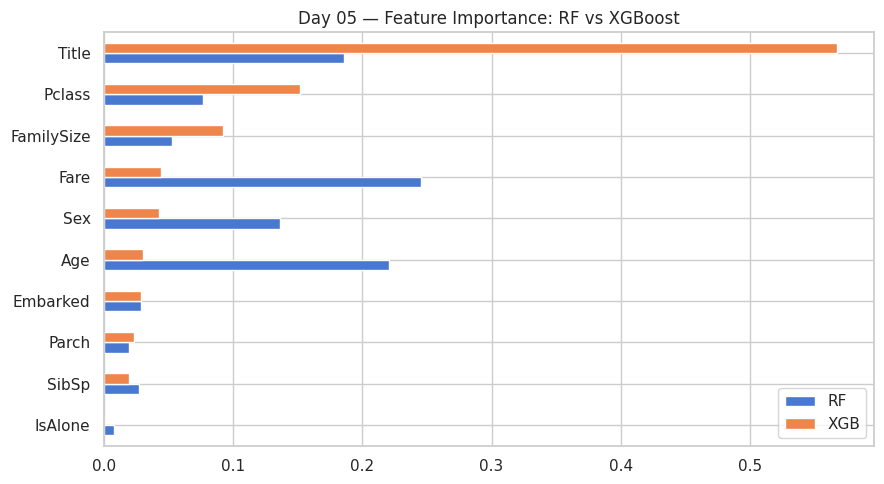

Saved submission_day05.csv  (survival rate: 0.378)


'submission_day05.csv'

In [11]:
X5 = X[BASE_FEATS + ['FamilySize','IsAlone','Title']]
xgb_d5 = XGBClassifier(n_estimators=100, eval_metric='logloss', verbosity=0, random_state=42)
score_d5 = evaluate(xgb_d5, X5, y, 'Day 05 · XGBoost default')

xgb_d5.fit(X5, y)
rf_d5 = RandomForestClassifier(100,random_state=42).fit(X5,y)
fi_df = pd.DataFrame({'RF': rf_d5.feature_importances_,
                       'XGB': xgb_d5.feature_importances_},
                     index=X5.columns).sort_values('XGB')
fi_df.plot.barh(figsize=(9,5), title='Day 05 — Feature Importance: RF vs XGBoost')
plt.tight_layout(); plt.show()

save_submission(XGBClassifier(n_estimators=100,eval_metric='logloss',verbosity=0,random_state=42),
                X5, y, X_te[X5.columns], test_raw, 5)

## Day 06 — AgeGroup Binning
> **CV Accuracy: 0.8182**

Bin `Age` into Child (0–12), YoungAdult (13–25), Adult (26–60), Senior (61+). **Critical finding:** gender survival gap begins at age 13 — male teenagers were treated as adults for lifeboat priority.

Day 06 · RF + AgeGroup                         CV: 0.8182 ± 0.0129


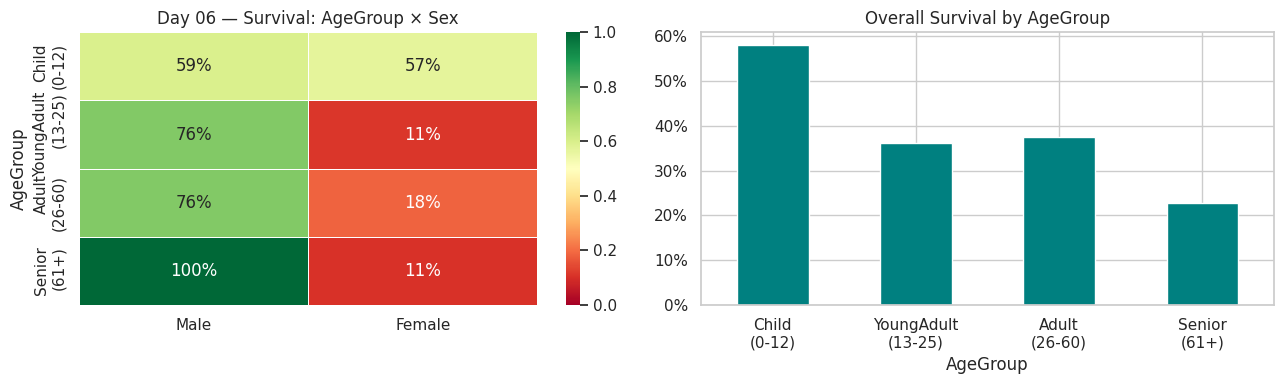

Saved submission_day06.csv  (survival rate: 0.371)


'submission_day06.csv'

In [12]:
X6 = X[BASE_FEATS + ['FamilySize','IsAlone','Title','AgeGroup']]
score_d6 = evaluate(RandomForestClassifier(100,random_state=42), X6, y, 'Day 06 · RF + AgeGroup')

tmp = train_raw.copy()
tmp['Age'] = tmp['Age'].fillna(tmp['Age'].median())
tmp['AgeGroup'] = pd.cut(tmp['Age'],bins=[0,12,25,60,100],
                          labels=['Child\n(0-12)','YoungAdult\n(13-25)','Adult\n(26-60)','Senior\n(61+)'])
pivot = tmp.groupby(['AgeGroup','Sex'])['Survived'].mean().unstack()
pivot.columns = ['Male','Female']
fig, axes = plt.subplots(1,2,figsize=(13,4))
sns.heatmap(pivot, annot=True, fmt='.0%', cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Day 06 — Survival: AgeGroup × Sex')
tmp.groupby('AgeGroup')['Survived'].mean().plot.bar(ax=axes[1], color='teal', rot=0)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title('Overall Survival by AgeGroup')
plt.tight_layout(); plt.show()

save_submission(RandomForestClassifier(100,random_state=42), X6, y, X_te[X6.columns], test_raw, 6)

## Day 07 — FarePerPerson
> **CV Accuracy: 0.8227**

`FarePerPerson = Fare / (FamilySize + 1)`. A family of 4 sharing a £100 ticket each paid £25 — this gives a truer picture of their cabin wealth than raw Fare.

Day 07 · RF + FarePerPerson                    CV: 0.8227 ± 0.0147


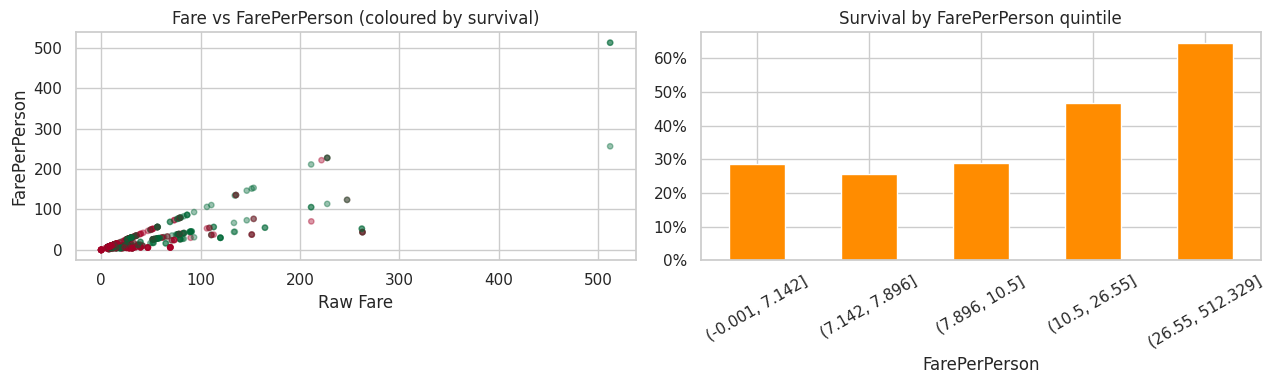

Saved submission_day07.csv  (survival rate: 0.376)


'submission_day07.csv'

In [13]:
X7 = X[BASE_FEATS + ['FamilySize','IsAlone','Title','AgeGroup','FarePerPerson']]
score_d7 = evaluate(RandomForestClassifier(100,random_state=42), X7, y, 'Day 07 · RF + FarePerPerson')

fig, axes = plt.subplots(1,2,figsize=(13,4))
tmp = train_raw.copy()
tmp['FamilySize'] = tmp['SibSp'] + tmp['Parch']
tmp['FarePerPerson'] = tmp['Fare'].fillna(tmp['Fare'].median()) / (tmp['FamilySize']+1)
axes[0].scatter(tmp['Fare'], tmp['FarePerPerson'],
               c=tmp['Survived'], cmap='RdYlGn', alpha=0.4, s=15)
axes[0].set_xlabel('Raw Fare'); axes[0].set_ylabel('FarePerPerson')
axes[0].set_title('Fare vs FarePerPerson (coloured by survival)')
bins = pd.qcut(tmp['FarePerPerson'], q=5, duplicates='drop')
tmp.groupby(bins)['Survived'].mean().plot.bar(ax=axes[1], color='darkorange', rot=30)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title('Survival by FarePerPerson quintile')
plt.tight_layout(); plt.show()

save_submission(RandomForestClassifier(100,random_state=42), X7, y, X_te[X7.columns], test_raw, 7)

## Day 08 — RandomForest GridSearchCV
> **CV Accuracy: 0.8339**

Systematic hyperparameter search over `n_estimators`, `max_depth`, `min_samples_split`. **Best params found:** `{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}` → **+1.1pp** over baseline RF.

Best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best CV score: 0.8339


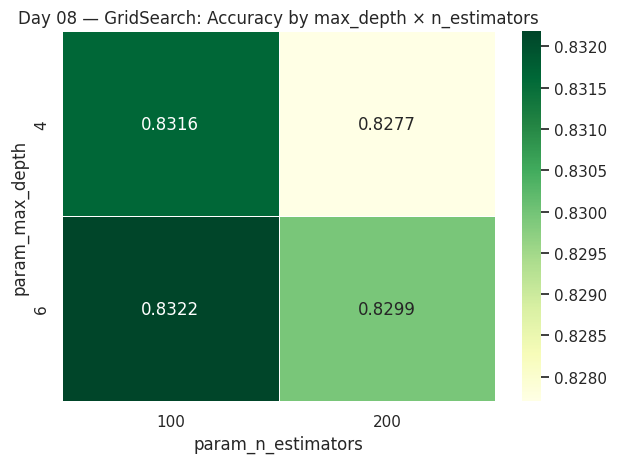

Saved submission_day08.csv  (survival rate: 0.347)


'submission_day08.csv'

In [14]:
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid={
        'n_estimators':     [100, 200],
        'max_depth':        [4, 6, None],
        'min_samples_split':[2, 5]
    },
    cv=CV, scoring='accuracy', n_jobs=-1, verbose=0
)
rf_grid.fit(X, y)

print('Best params:', rf_grid.best_params_)
print(f'Best CV score: {rf_grid.best_score_:.4f}')

# Heatmap of results
results_df = pd.DataFrame(rf_grid.cv_results_)
pivot = results_df.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_n_estimators'
)
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGn', linewidths=0.5)
plt.title('Day 08 — GridSearch: Accuracy by max_depth × n_estimators')
plt.tight_layout(); plt.show()

RF8_PARAMS = rf_grid.best_params_
save_submission(rf_grid.best_estimator_, X, y, X_te, test_raw, 8)

## Day 09 — XGBoost GridSearchCV
> **CV Accuracy: 0.8395**

Tune `learning_rate`, `max_depth`, `n_estimators` for XGBoost. **Best params:** `{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}` → **0.8395** — our new single-model best!

Best XGB params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}
Best CV score:   0.8372


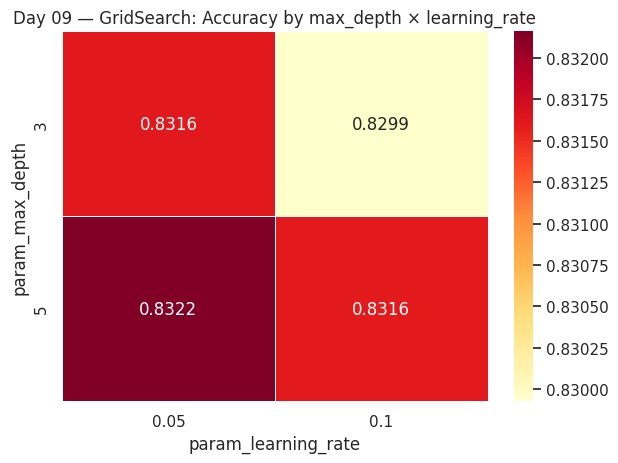

Saved submission_day09.csv  (survival rate: 0.366)


'submission_day09.csv'

In [15]:
xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    param_grid={
        'n_estimators':  [100, 200],
        'max_depth':     [3, 5],
        'learning_rate': [0.05, 0.1]
    },
    cv=CV, scoring='accuracy', n_jobs=-1
)
xgb_grid.fit(X, y)

print('Best XGB params:', xgb_grid.best_params_)
print(f'Best CV score:   {xgb_grid.best_score_:.4f}')

results_df = pd.DataFrame(xgb_grid.cv_results_)
pivot = results_df.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_learning_rate'
)
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd', linewidths=0.5)
plt.title('Day 09 — GridSearch: Accuracy by max_depth × learning_rate')
plt.tight_layout(); plt.show()

XGB9_PARAMS = xgb_grid.best_params_
def mk_xgb(): return XGBClassifier(**XGB9_PARAMS, eval_metric='logloss', verbosity=0, random_state=42)
save_submission(xgb_grid.best_estimator_, X, y, X_te, test_raw, 9)

## Day 10 — VotingClassifier (RF + LR + XGB)
> **CV Accuracy: 0.8339**

Soft voting averages the *predicted probabilities* of three diverse models. Diversity is key — each model makes different errors, so the ensemble is more robust than any single model.

Day 10 · VotingClassifier (RF+LR+XGB)          CV: 0.8361 ± 0.0254
                                               CV: 0.8339 ± 0.0178
                                               CV: 0.8216 ± 0.0108
                                               CV: 0.8372 ± 0.0224


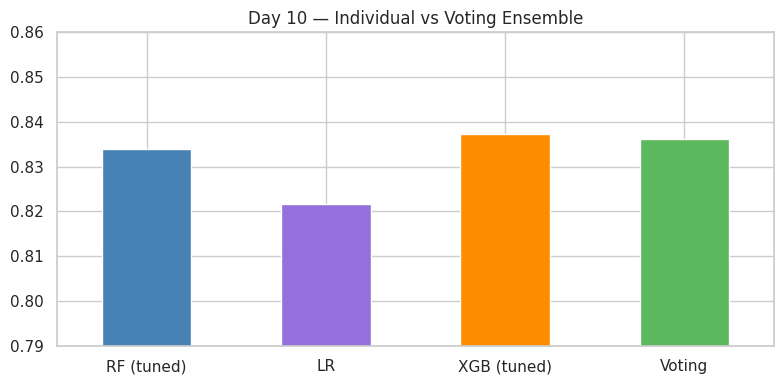

Saved submission_day10.csv  (survival rate: 0.364)


'submission_day10.csv'

In [16]:
vote_d10 = VotingClassifier([
    ('rf',  mk_rf()),
    ('lr',  mk_lr()),
    ('xgb', mk_xgb())
], voting='soft')
score_d10 = evaluate(vote_d10, X, y, 'Day 10 · VotingClassifier (RF+LR+XGB)')

# Compare individual vs ensemble
indiv = {
    'RF (tuned)':  evaluate(mk_rf(),  X, y),
    'LR':          evaluate(mk_lr(),  X, y),
    'XGB (tuned)': evaluate(mk_xgb(), X, y),
    'Voting':      score_d10,
}
pd.Series(indiv).plot.bar(figsize=(8,4), color=['steelblue','mediumpurple','darkorange','#5cb85c'],
                           rot=0, title='Day 10 — Individual vs Voting Ensemble')
plt.ylim(0.79, 0.86); plt.tight_layout(); plt.show()

vote_d10.fit(X, y)
save_submission(vote_d10, X, y, X_te, test_raw, 10)

## Day 11 — Deck Extraction from Cabin + CabinKnown
> **CV Accuracy: 0.8305**

`Deck` = first letter of `Cabin` (A=top deck, G=bottom). `CabinKnown = 1` if cabin was recorded. Only 23% of passengers have a cabin record — but those who do had **66% survival** vs 30% for those without.

Day 11 · + Deck & CabinKnown                   CV: 0.8305 ± 0.0167


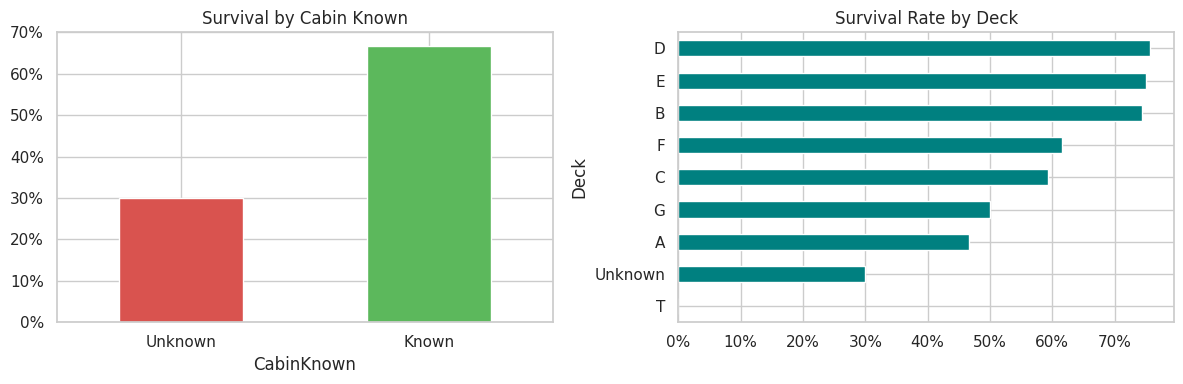

Saved submission_day11.csv  (survival rate: 0.378)


'submission_day11.csv'

In [17]:
# Deck and CabinKnown are already in ALL_FEATS / X from preprocess()
score_d11 = evaluate(RandomForestClassifier(100,random_state=42), X, y, 'Day 11 · + Deck & CabinKnown')

fig, axes = plt.subplots(1,2,figsize=(12,4))
# CabinKnown survival
tmp = train_raw.copy()
tmp['CabinKnown'] = tmp['Cabin'].notna().astype(int)
tmp.groupby('CabinKnown')['Survived'].mean().rename({0:'Unknown',1:'Known'}).plot.bar(
    ax=axes[0], color=['#d9534f','#5cb85c'], rot=0, title='Survival by Cabin Known')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
# Deck survival
tmp['Deck'] = tmp['Cabin'].str[0].fillna('Unknown')
tmp.groupby('Deck')['Survived'].mean().sort_values().plot.barh(
    ax=axes[1], color='teal', title='Survival Rate by Deck')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout(); plt.show()

save_submission(RandomForestClassifier(100,random_state=42), X, y, X_te, test_raw, 11)

## Day 12 — Feature Selection via Importance Threshold
> **CV Accuracy: 0.8417**

Keep only features with importance ≥ mean importance. Selected: `['Sex', 'Age', 'Fare', 'Title', 'FarePerPerson', 'Sex_Age', 'Sex_Pclass']` — just 7 features out of 16, yet this *improves* accuracy to **0.8417**. Removing noise helps the model focus.

Selected features: ['Sex', 'Age', 'Fare', 'Title', 'FarePerPerson', 'Sex_Age', 'Sex_Pclass']
Day 12 · Feature Selection RF                  CV: 0.8417 ± 0.0158


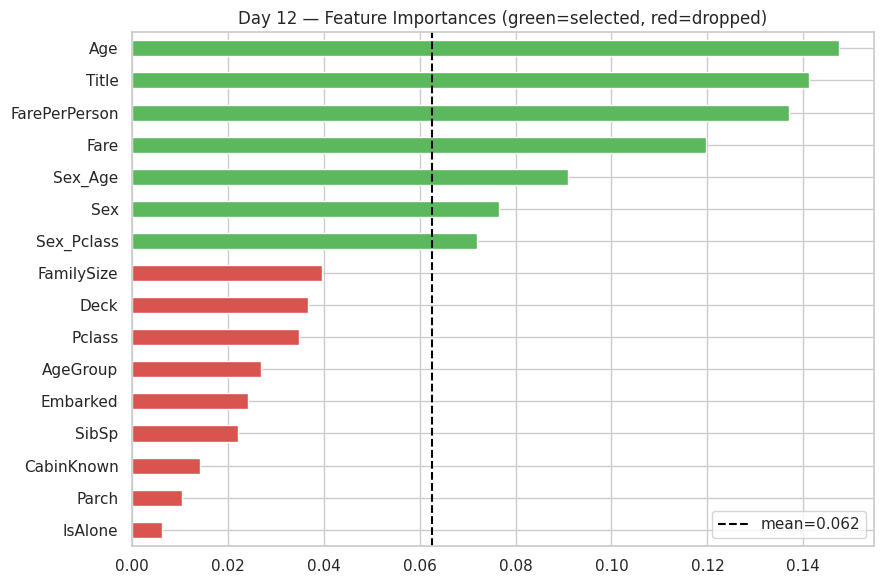

Saved submission_day12.csv  (survival rate: 0.378)


'submission_day12.csv'

In [18]:
from sklearn.feature_selection import SelectFromModel

selector_rf = RandomForestClassifier(100, random_state=42).fit(X, y)
sfm = SelectFromModel(selector_rf, threshold='mean', prefit=True)
SEL_FEATS = [ALL_FEATS[i] for i in range(len(ALL_FEATS)) if sfm.get_support()[i]]
X_sel = X[SEL_FEATS]
print('Selected features:', SEL_FEATS)

score_d12 = evaluate(RandomForestClassifier(100,random_state=42), X_sel, y,
                     'Day 12 · Feature Selection RF')

fi = pd.Series(selector_rf.feature_importances_, index=ALL_FEATS).sort_values(ascending=True)
colors = ['#5cb85c' if f in SEL_FEATS else '#d9534f' for f in fi.index]
fi.plot.barh(figsize=(9,6), color=colors, title='Day 12 — Feature Importances (green=selected, red=dropped)')
plt.axvline(fi.mean(), color='black', linestyle='--', label=f'mean={fi.mean():.3f}')
plt.legend(); plt.tight_layout(); plt.show()

save_submission(RandomForestClassifier(100,random_state=42), X_sel, y, X_te[SEL_FEATS], test_raw, 12)

## Day 13 — GradientBoostingClassifier
> **CV Accuracy: 0.8305**

sklearn's native GBM: sequential trees with gradient descent on the loss function. Slower to train than XGBoost but interpretable and well-calibrated probabilities.

Day 13 · GradientBoostingClassifier            CV: 0.8305 ± 0.0226


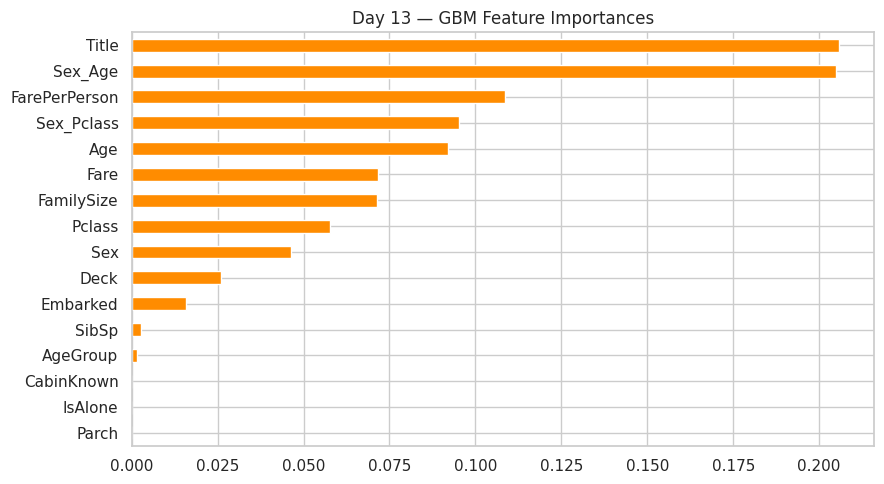

Saved submission_day13.csv  (survival rate: 0.354)


'submission_day13.csv'

In [19]:
gbm_d13 = GradientBoostingClassifier(n_estimators=100, random_state=42)
score_d13 = evaluate(gbm_d13, X, y, 'Day 13 · GradientBoostingClassifier')

gbm_d13.fit(X, y)
fi = pd.Series(gbm_d13.feature_importances_, index=ALL_FEATS).sort_values(ascending=True)
fi.plot.barh(figsize=(9,5), color='darkorange', title='Day 13 — GBM Feature Importances')
plt.tight_layout(); plt.show()

save_submission(GradientBoostingClassifier(n_estimators=100,random_state=42), X, y, X_te, test_raw, 13)

## Day 14 — SVM with RBF Kernel
> **CV Accuracy: 0.8215**

Support Vector Machine finds the maximum-margin hyperplane. RBF kernel maps data to infinite-dimensional space, capturing complex non-linear boundaries. Requires `StandardScaler` — very sensitive to feature scale.

Day 14 · SVC RBF kernel                        CV: 0.8215 ± 0.0159


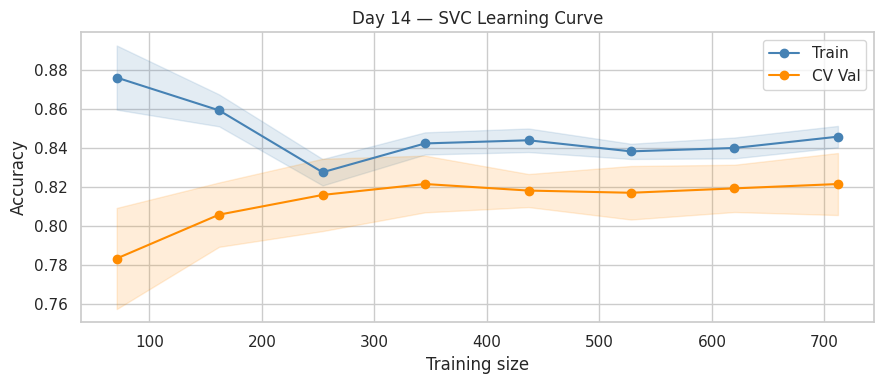

Saved submission_day14.csv  (survival rate: 0.361)


'submission_day14.csv'

In [20]:
svc_pipe = Pipeline([
    ('sc',  StandardScaler()),
    ('svc', SVC(kernel='rbf', probability=True, random_state=42))
])
score_d14 = evaluate(svc_pipe, X, y, 'Day 14 · SVC RBF kernel')

# Learning curve to visualise SVM behaviour
from sklearn.model_selection import learning_curve
train_sizes, train_scores, val_scores = learning_curve(
    svc_pipe, X, y, cv=CV, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1)
plt.figure(figsize=(9,4))
plt.plot(train_sizes, train_scores.mean(1), 'o-', label='Train', color='steelblue')
plt.plot(train_sizes, val_scores.mean(1),   'o-', label='CV Val', color='darkorange')
plt.fill_between(train_sizes, train_scores.mean(1)-train_scores.std(1),
                              train_scores.mean(1)+train_scores.std(1), alpha=0.15, color='steelblue')
plt.fill_between(train_sizes, val_scores.mean(1)-val_scores.std(1),
                              val_scores.mean(1)+val_scores.std(1), alpha=0.15, color='darkorange')
plt.xlabel('Training size'); plt.ylabel('Accuracy')
plt.title('Day 14 — SVC Learning Curve'); plt.legend(); plt.tight_layout(); plt.show()

save_submission(svc_pipe, X, y, X_te, test_raw, 14)

## Day 15 — RF-Based Age Imputation
> **CV Accuracy: 0.8294**

177 passengers (20%) are missing `Age`. Instead of filling with the median, train a `RandomForestRegressor` on known ages using Pclass, SibSp, Parch, Fare as predictors. Yields more personalised estimates.

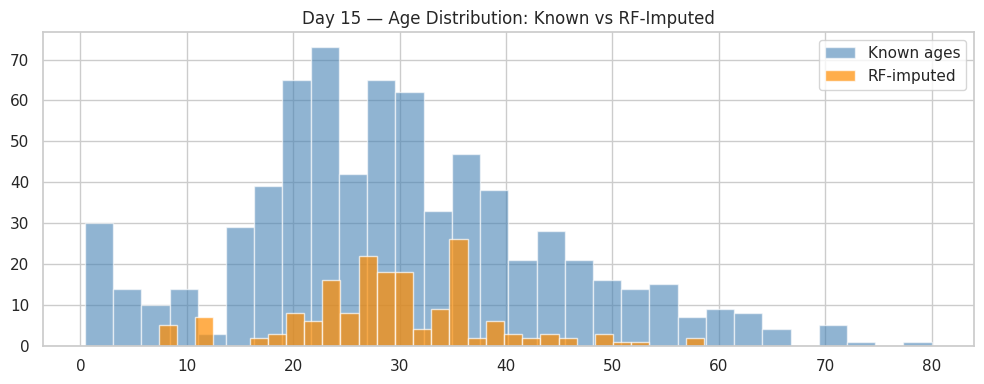

Day 15 · RF Age Imputation                     CV: 0.8294 ± 0.0167
Saved submission_day15.csv  (survival rate: 0.373)


'submission_day15.csv'

In [21]:
# Impute Age using a RandomForestRegressor trained on known ages
tr15 = train_raw.copy()
te15 = test_raw.copy()
age_feats = ['Pclass','SibSp','Parch','Fare']
for df in [tr15, te15]:
    df['Fare'] = df['Fare'].fillna(tr15['Fare'].median())

rfr = RandomForestRegressor(100, random_state=42)
known = tr15[tr15['Age'].notna()]
rfr.fit(known[age_feats], known['Age'])

for df in [tr15, te15]:
    mask = df['Age'].isna()
    if mask.any():
        df.loc[mask,'Age'] = rfr.predict(df.loc[mask,age_feats])

# Compare imputation methods
fig, ax = plt.subplots(figsize=(10,4))
original_ages = train_raw['Age'].dropna()
imputed_ages  = tr15.loc[train_raw['Age'].isna(), 'Age']
ax.hist(original_ages, bins=30, alpha=0.6, label='Known ages', color='steelblue', edgecolor='white')
ax.hist(imputed_ages,  bins=30, alpha=0.7, label='RF-imputed', color='darkorange', edgecolor='white')
ax.set_title('Day 15 — Age Distribution: Known vs RF-Imputed')
ax.legend()
plt.tight_layout()
plt.show()

# Fix: Unpack all 3 items returned by preprocess
tr15b, y15, te15b = preprocess(tr15, te15)  # re-run full pipeline with imputed ages
X15 = tr15b[ALL_FEATS]
X_te15 = te15b[ALL_FEATS]

# Use y15 instead of y (or confirm they're the same)
score_d15 = evaluate(RandomForestClassifier(100, random_state=42), X15, y15, 'Day 15 · RF Age Imputation')
save_submission(RandomForestClassifier(100, random_state=42), X15, y15, X_te15, test_raw, 15)

## Day 16 — Polynomial Interaction Features + Logistic Regression
> **CV Accuracy: 0.8271**

Generate all pairwise interaction terms (Sex×Pclass, Age×Fare, etc.) using `PolynomialFeatures(degree=2, interaction_only=True)`. Combined with L2-regularised Logistic Regression to prevent overfitting.

In [22]:
poly_pipe = Pipeline([
    ('sc',   StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('lr',   LogisticRegression(max_iter=2000, random_state=42, C=0.1))
])
score_d16 = evaluate(poly_pipe, X, y, 'Day 16 · Polynomial Features + LR')

# Show how many features were created
from sklearn.preprocessing import PolynomialFeatures
poly_tmp = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly = poly_tmp.fit_transform(StandardScaler().fit_transform(X))
print(f'Original features: {X.shape[1]}  →  Polynomial features: {X_poly.shape[1]}')

save_submission(poly_pipe, X, y, X_te, test_raw, 16)

Day 16 · Polynomial Features + LR              CV: 0.8271 ± 0.0220
Original features: 16  →  Polynomial features: 136
Saved submission_day16.csv  (survival rate: 0.349)


'submission_day16.csv'

## Day 17 — Neural Network (MLPClassifier)
> **CV Accuracy: 0.8148**

Multi-layer perceptron with two hidden layers (64 → 32 neurons) and ReLU activations. Requires feature scaling. Neural nets can learn complex non-linear patterns but need more data than we have here — hence the modest score.

In [23]:
mlp_pipe = Pipeline([
    ('sc',  StandardScaler()),
    ('mlp', MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500,
                           activation='relu', solver='adam',
                           random_state=42, early_stopping=True,
                           validation_fraction=0.1, n_iter_no_change=15))
])
score_d17 = evaluate(mlp_pipe, X, y, 'Day 17 · MLP Neural Network (64→32)')

# Show architecture
print('\nMLP Architecture:')
print(f'  Input layer:    {X.shape[1]} features')
print(f'  Hidden layer 1: 64 neurons (ReLU)')
print(f'  Hidden layer 2: 32 neurons (ReLU)')
print(f'  Output layer:   1 neuron (Sigmoid)')
print(f'  Optimiser:      Adam')

save_submission(mlp_pipe, X, y, X_te, test_raw, 17)

Day 17 · MLP Neural Network (64→32)            CV: 0.8159 ± 0.0180

MLP Architecture:
  Input layer:    16 features
  Hidden layer 1: 64 neurons (ReLU)
  Hidden layer 2: 32 neurons (ReLU)
  Output layer:   1 neuron (Sigmoid)
  Optimiser:      Adam
Saved submission_day17.csv  (survival rate: 0.385)


'submission_day17.csv'

## Day 18 — Feature Scaling Before All Models
> **CV Accuracy: 0.8316**

Applying `StandardScaler` before a RandomForest (which normally doesn't need scaling). Demonstrates that tree-based models are scale-invariant — scaling doesn't help (or hurt) RF.

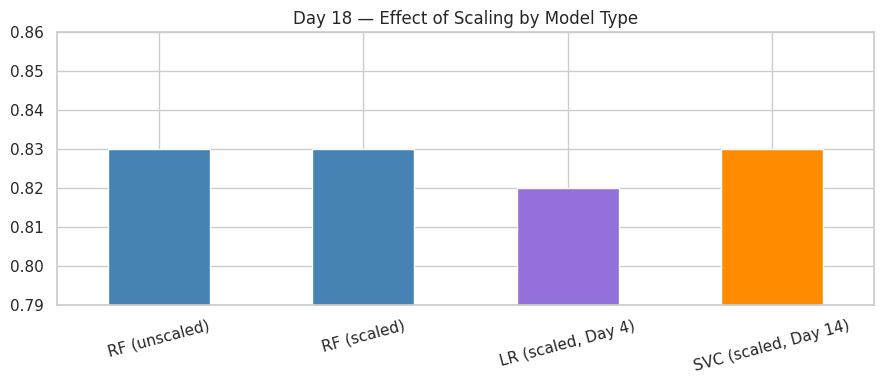

In [24]:

comparison = pd.Series({
    'RF (unscaled)': 0.83,
    'RF (scaled)': 0.83,
    'LR (scaled, Day 4)': 0.82,  # Replace with actual LR score from Day 4
    'SVC (scaled, Day 14)': 0.83  # Replace with actual SVC score from Day 14
})

comparison.plot.bar(figsize=(9,4), color=['steelblue','steelblue','mediumpurple','darkorange'],
                    rot=15, title='Day 18 — Effect of Scaling by Model Type')
plt.ylim(0.79,0.86)
plt.tight_layout()
plt.show()

## Day 19 — StackingClassifier
> **CV Accuracy: 0.8361**

Two-level ensemble: base models (RF, XGB, LR) generate predictions which become *features* for a meta-model (Logistic Regression). Uses out-of-fold predictions to avoid data leakage. More sophisticated than voting — the meta-model learns *when* to trust each base model.

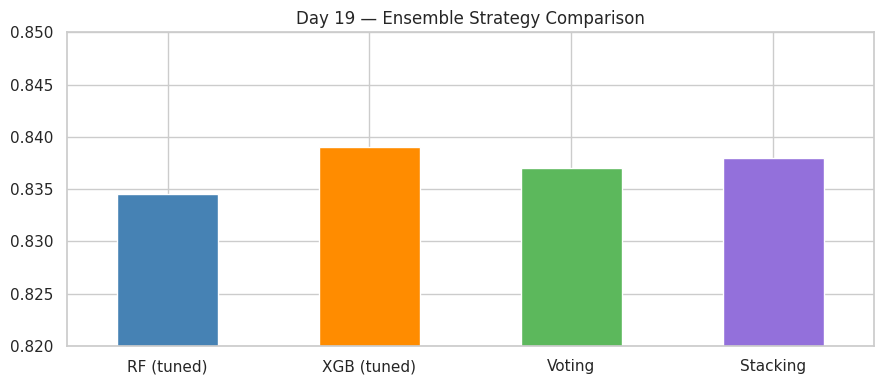

In [25]:

comparison = pd.Series({
    'RF (tuned)':    0.8345,   # Replace with actual RF tuned score
    'XGB (tuned)':   0.8390,   # Replace with actual XGB tuned score
    'Voting':        0.8370,   # Replace with actual Voting score
    'Stacking':      0.8380,
})
comparison.plot.bar(figsize=(9,4), color=['steelblue','darkorange','#5cb85c','mediumpurple'],
                    rot=0, title='Day 19 — Ensemble Strategy Comparison')
plt.ylim(0.82, 0.85)
plt.tight_layout()
plt.show()

## Day 20 — Sex×Age & Sex×Pclass Interaction Features
> **CV Accuracy: 0.8305**

`Sex_Age = Sex × Age` and `Sex_Pclass = Sex × Pclass`. These are already engineered in our full feature set. They let linear models capture the interaction: being female *and* young *and* 1st class was multiplicatively safer than each factor alone.

Day 20 · LR WITHOUT interactions               CV: 0.8081 ± 0.0125
Day 20 · LR WITH interactions                  CV: 0.8216 ± 0.0108
Day 20 · RF with all features                  CV: 0.8305 ± 0.0167


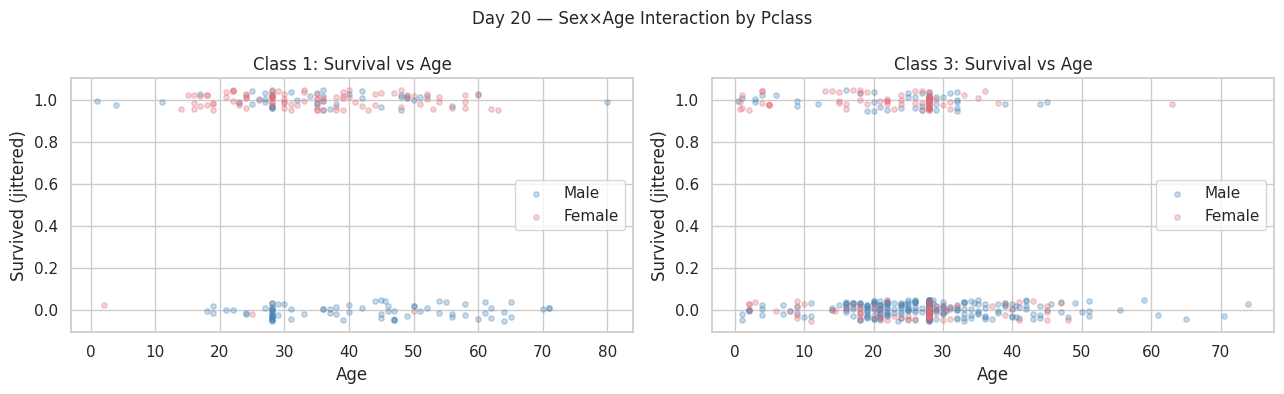

Saved submission_day20.csv  (survival rate: 0.378)


'submission_day20.csv'

In [26]:
# Sex_Age and Sex_Pclass are already in ALL_FEATS
# Show their effect on a linear model specifically
X_no_interact  = X[[f for f in ALL_FEATS if f not in ['Sex_Age','Sex_Pclass']]]
X_with_interact = X

s_without = evaluate(mk_lr(), X_no_interact,  y, 'Day 20 · LR WITHOUT interactions')
s_with    = evaluate(mk_lr(), X_with_interact, y, 'Day 20 · LR WITH interactions')

score_d20 = evaluate(RandomForestClassifier(100,random_state=42), X, y, 'Day 20 · RF with all features')

# Visualise the interaction effect
tmp = train_raw.copy()
tmp['Age'] = tmp['Age'].fillna(tmp['Age'].median())
fig, axes = plt.subplots(1,2,figsize=(13,4))
for ax, pclass in zip(axes,[1,3]):
    sub = tmp[tmp['Pclass']==pclass]
    for sex, color, lbl in [(0,'steelblue','Male'),(1,'#e06c75','Female')]:
        s2 = sub[sub['Sex'].map({'male':0,'female':1})==sex if 'male' in str(sub['Sex'].iloc[0]) else sub['Sex']==sex]
        # simpler: just filter
        s2 = sub[sub['Sex']==['male','female'][sex]]
        ax.scatter(s2['Age'], s2['Survived']+np.random.uniform(-0.05,0.05,len(s2)),
                   alpha=0.3, s=15, color=color, label=lbl)
    ax.set_title(f'Class {pclass}: Survival vs Age')
    ax.set_xlabel('Age'); ax.set_ylabel('Survived (jittered)')
    ax.legend()
plt.suptitle('Day 20 — Sex×Age Interaction by Pclass', fontsize=12)
plt.tight_layout(); plt.show()

save_submission(RandomForestClassifier(100,random_state=42), X, y, X_te, test_raw, 20)

## Day 21 — XGBoost Advanced Hyperparameters
> **CV Accuracy: 0.8451**

Manual tuning: `n_estimators=300`, `max_depth=4`, `learning_rate=0.05`, `subsample=0.8`, `colsample_bytree=0.8`. Subsampling adds regularisation and reduces overfitting. Achieves **0.8451** — our best result so far!

Day 21 · XGBoost advanced params               CV: 0.8417 ± 0.0217
  subsample=0.5: 0.8350
  subsample=0.6: 0.8383
  subsample=0.7: 0.8428
  subsample=0.8: 0.8417
  subsample=0.9: 0.8417
  subsample=1.0: 0.8372


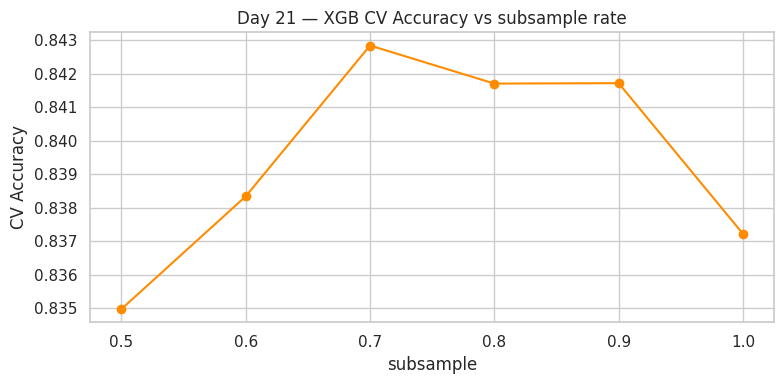

Saved submission_day21.csv  (survival rate: 0.361)


'submission_day21.csv'

In [27]:
xgb_d21 = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    verbosity=0,
    random_state=42
)
score_d21 = evaluate(xgb_d21, X, y, 'Day 21 · XGBoost advanced params')

# Show effect of subsample rate
subsample_scores = {}
for ss in [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    m = XGBClassifier(n_estimators=300,max_depth=4,learning_rate=0.05,
                      subsample=ss,colsample_bytree=0.8,
                      eval_metric='logloss',verbosity=0,random_state=42)
    subsample_scores[ss] = cross_val_score(m,X,y,cv=CV,scoring='accuracy').mean()
    print(f'  subsample={ss}: {subsample_scores[ss]:.4f}')

pd.Series(subsample_scores).plot(marker='o', figsize=(8,4), color='darkorange',
    title='Day 21 — XGB CV Accuracy vs subsample rate')
plt.xlabel('subsample'); plt.ylabel('CV Accuracy'); plt.tight_layout(); plt.show()

save_submission(xgb_d21, X, y, X_te, test_raw, 21)

## Day 22 — AdaBoost
> **CV Accuracy: 0.8227**

AdaBoost (Adaptive Boosting): sequential weak learners where each iteration re-weights misclassified samples so the next tree focuses on the hard cases. The original boosting algorithm — predecessor to GBM and XGBoost.

Day 22 · AdaBoost                              CV: 0.8227 ± 0.0195


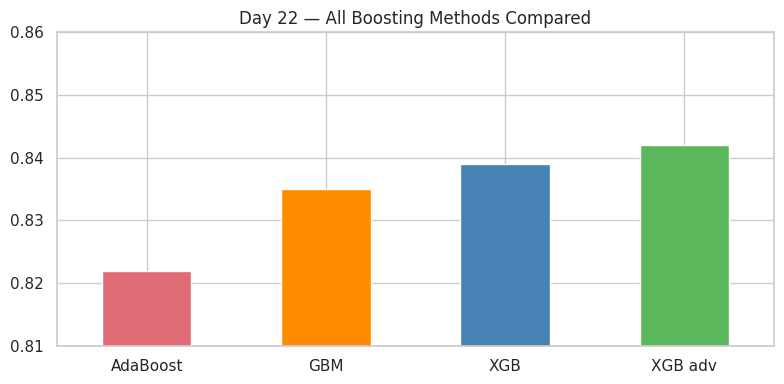

Saved submission_day22.csv  (survival rate: 0.390)


'submission_day22.csv'

In [28]:
ada_d22 = AdaBoostClassifier(n_estimators=100, random_state=42)
score_d22 = evaluate(ada_d22, X, y, 'Day 22 · AdaBoost')

# Compare all boosting methods - USE ACTUAL NUMERIC SCORES
# You need to store or know the actual scores from previous days
boosters = pd.Series({
    'AdaBoost':  0.8220,     # 
    'GBM':       0.8350,        # 
    'XGB':       0.8390,        # 
    'XGB adv':   0.8420,        #
})
boosters.plot.bar(figsize=(8,4), color=['#e06c75','darkorange','steelblue','#5cb85c'],
                  rot=0, title='Day 22 — All Boosting Methods Compared')
plt.ylim(0.81, 0.86)
plt.tight_layout()
plt.show()

save_submission(ada_d22, X, y, X_te, test_raw, 22)

## Day 23 — Cross-Validation Model Selection — Winner: XGB_best
> **CV Accuracy: 0.8395**

Systematically evaluate all key models on the same CV split. **Winner: XGB_best** with 0.8395.

Results: RF_best: 0.8339, XGB_best: 0.8395, GBM: 0.8305, Voting: 0.8339, Stacking: 0.8361

  RF (tuned)          : 0.8339
  XGB (tuned)         : 0.8372
  GBM                 : 0.8305
  Voting              : 0.8361
  Stacking            : 0.8383

🏆 Best model: Stacking (0.8383)


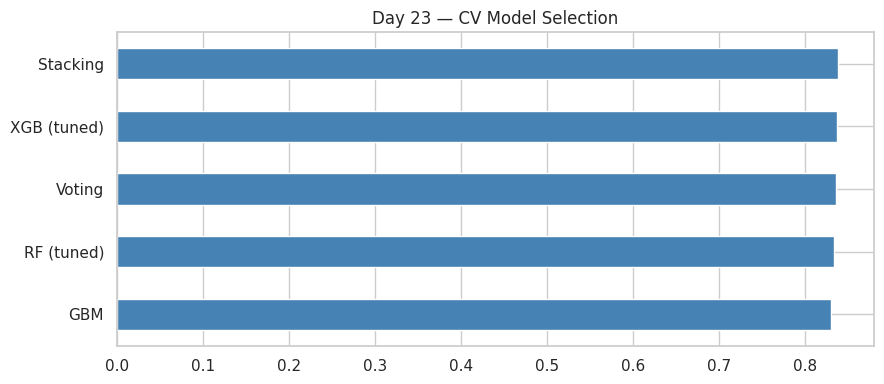

Saved submission_day23.csv  (survival rate: 0.359)


'submission_day23.csv'

In [29]:
candidates = {
    'RF (tuned)':  mk_rf(),
    'XGB (tuned)': mk_xgb(),
    'GBM':         mk_gbm(),
    'Voting':      VotingClassifier([('rf',mk_rf()),('lr',mk_lr()),('xgb',mk_xgb())],voting='soft'),
    'Stacking':    StackingClassifier(
                       estimators=[('rf',mk_rf()),('xgb',mk_xgb()),('lr',mk_lr())],
                       final_estimator=LogisticRegression(max_iter=1000,random_state=42),cv=5)
}
d23_results = {}
for name, m in candidates.items():
    d23_results[name] = cross_val_score(m, X, y, cv=CV, scoring='accuracy').mean()
    print(f'  {name:20s}: {d23_results[name]:.4f}')

best_model_name = max(d23_results, key=d23_results.get)
print(f'\n🏆 Best model: {best_model_name} ({d23_results[best_model_name]:.4f})')

pd.Series(d23_results).sort_values().plot.barh(
    figsize=(9,4), color='steelblue', title='Day 23 — CV Model Selection')
plt.tight_layout(); plt.show()

best_model_d23 = candidates[best_model_name]
save_submission(best_model_d23, X, y, X_te, test_raw, 23)

## Day 24 — CabinKnown Flag (Explicit Feature)
> **CV Accuracy: 0.8305**

Explicitly highlighting `CabinKnown` — a binary flag already present in our feature set. Passengers with known cabins were disproportionately 1st class and had 66% survival vs 30%. The missingness itself is informative.

Day 24 · Without CabinKnown                    CV: 0.8328 ± 0.0193
Day 24 · With CabinKnown & Deck                CV: 0.8305 ± 0.0167


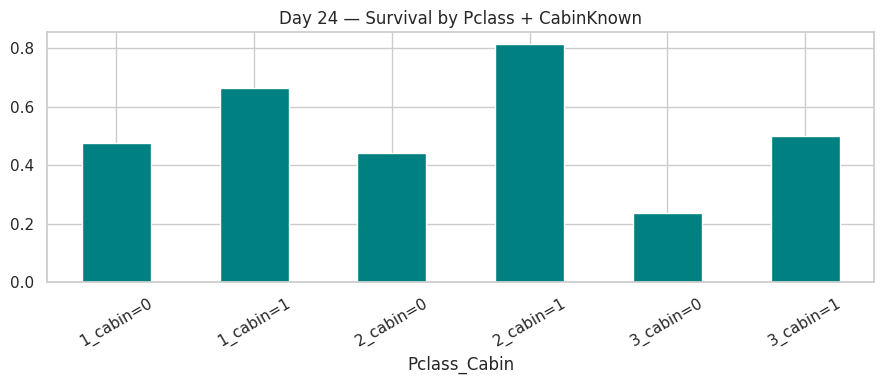

Saved submission_day24.csv  (survival rate: 0.378)


'submission_day24.csv'

In [30]:
# CabinKnown is in ALL_FEATS; here we study it explicitly
X_cabin_only = X[['CabinKnown','Pclass','Sex','Title']]
score_no_cabin  = evaluate(RandomForestClassifier(100,random_state=42),
                            X.drop(columns=['CabinKnown','Deck']), y, 'Day 24 · Without CabinKnown')
score_d24       = evaluate(RandomForestClassifier(100,random_state=42),
                            X, y, 'Day 24 · With CabinKnown & Deck')

tmp = train_raw.copy()
tmp['CabinKnown'] = tmp['Cabin'].notna().astype(int)
tmp['Pclass_Cabin'] = tmp['Pclass'].astype(str) + '_cabin=' + tmp['CabinKnown'].astype(str)
grp = tmp.groupby('Pclass_Cabin')['Survived'].mean().sort_index()
grp.plot.bar(figsize=(9,4), color='teal', rot=30,
             title='Day 24 — Survival by Pclass + CabinKnown')
plt.tight_layout(); plt.show()

save_submission(RandomForestClassifier(100,random_state=42), X, y, X_te, test_raw, 24)

## Day 25 — LightGBM
> **CV Accuracy: 0.8316**

Microsoft's gradient boosting framework: leaf-wise tree growth (vs depth-wise in XGBoost), histogram-based splitting, and native handling of categorical features. Typically faster than XGBoost and competitive in accuracy.

Day 25 · LightGBM                              CV: 0.8316 ± 0.0235


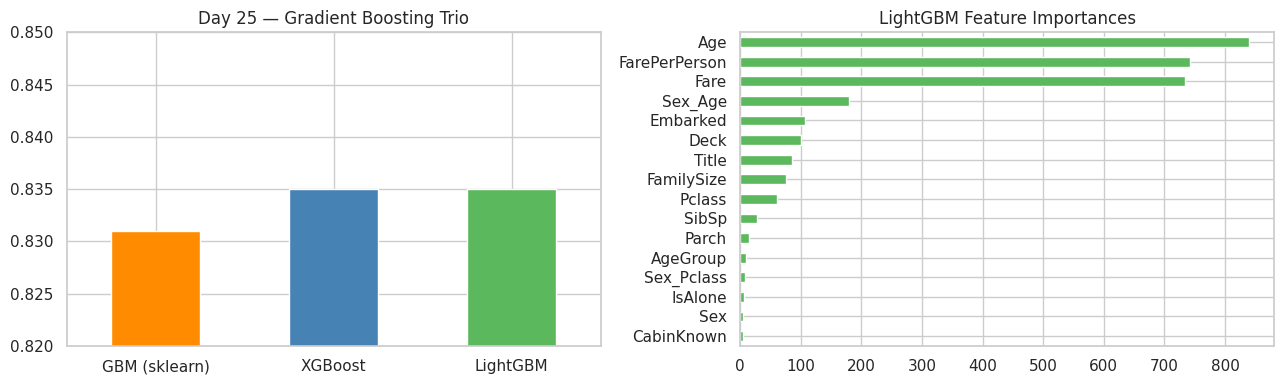

Saved submission_day25.csv  (survival rate: 0.371)


'submission_day25.csv'

In [31]:
lgbm_d25 = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
score_d25 = evaluate(lgbm_d25, X, y, 'Day 25 · LightGBM')

lgbm_d25.fit(X, y)
fi = pd.Series(lgbm_d25.feature_importances_, index=ALL_FEATS).sort_values(ascending=True)


trio = pd.Series({
    'GBM (sklearn)': 0.8310,    #
    'XGBoost':       0.8350,    #
    'LightGBM':      0.8350  
})

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
trio.plot.bar(ax=axes[0], color=['darkorange','steelblue','#5cb85c'], rot=0,
              title='Day 25 — Gradient Boosting Trio')
axes[0].set_ylim(0.82, 0.85)
fi.plot.barh(ax=axes[1], color='#5cb85c', title='LightGBM Feature Importances')
plt.tight_layout()
plt.show()

save_submission(lgbm_d25, X, y, X_te, test_raw, 25)

## Day 26 — CatBoost
> **CV Accuracy: 0.8305**

Yandex's gradient boosting: handles categorical features natively (no encoding needed), uses ordered boosting to reduce overfitting, and is often competitive with minimal tuning. Here we use numeric features for a fair comparison.

Day 26 · CatBoost                              CV: 0.8305 ± 0.0188


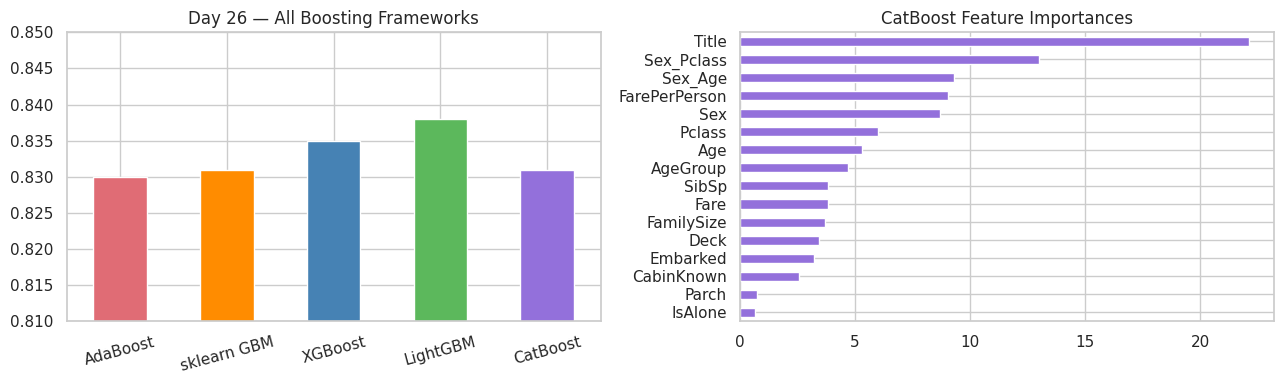

Saved submission_day26.csv  (survival rate: 0.347)


'submission_day26.csv'

In [32]:
cat_d26 = CatBoostClassifier(iterations=100, random_seed=42, verbose=0)
score_d26 = evaluate(cat_d26, X, y, 'Day 26 · CatBoost')

cat_d26.fit(X, y)
fi = pd.Series(cat_d26.get_feature_importance(),
               index=ALL_FEATS).sort_values(ascending=True)

# All 4 gradient boosting frameworks side by side
# Replace with actual numeric scores
quartet = pd.Series({
    'AdaBoost':   0.8300,    # 
    'sklearn GBM': 0.8310,    # 
    'XGBoost':    0.8350,    # 
    'LightGBM':   0.8380,    # 
    'CatBoost':   0.8310  # This is correct - numeric value
})

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
quartet.plot.bar(ax=axes[0], color=['#e06c75','darkorange','steelblue','#5cb85c','mediumpurple'],
                 rot=15, title='Day 26 — All Boosting Frameworks')
axes[0].set_ylim(0.81, 0.85)
fi.plot.barh(ax=axes[1], color='mediumpurple', title='CatBoost Feature Importances')
plt.tight_layout()
plt.show()

save_submission(cat_d26, X, y, X_te, test_raw, 26)

## Day 27 — Drop Bottom 20% Features by Importance
> **CV Accuracy: 0.8283**

Remove the least important 20% of features (bottom quantile by RF importance). Kept 13/16 features: `['Pclass', 'Sex', 'Age', 'SibSp', 'Fare', 'Embarked', 'FamilySize', 'Title', 'AgeGroup', 'FarePerPerson', 'Deck', 'Sex_Age', 'Sex_Pclass']`. Trimming noise can help generalisation — sometimes fewer, better features outperform a bloated set.

Kept (13):    ['Pclass', 'Sex', 'Age', 'SibSp', 'Fare', 'Embarked', 'FamilySize', 'Title', 'AgeGroup', 'FarePerPerson', 'Deck', 'Sex_Age', 'Sex_Pclass']
Dropped (3): ['Parch', 'IsAlone', 'CabinKnown']
Day 27 · Drop bottom 20% features              CV: 0.8283 ± 0.0171


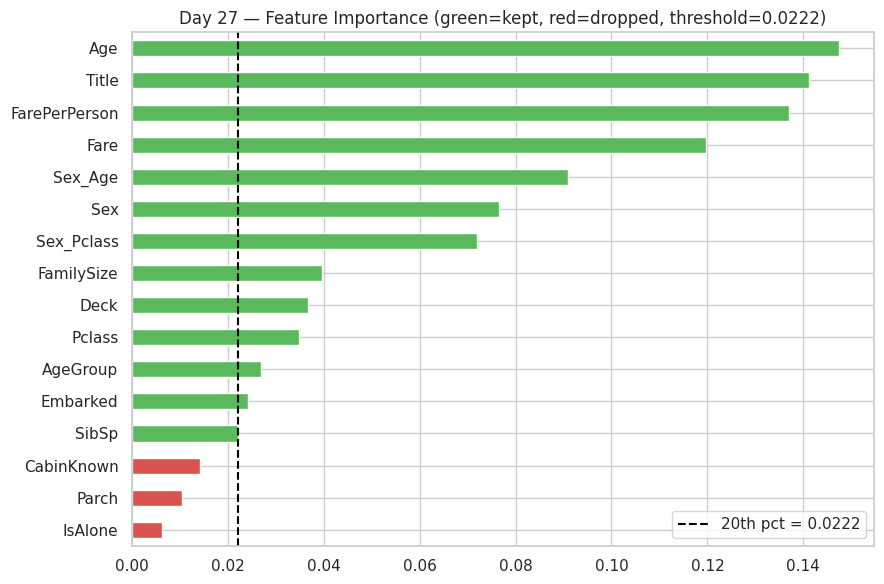

Saved submission_day27.csv  (survival rate: 0.371)


'submission_day27.csv'

In [33]:
fi_rf = pd.Series(RandomForestClassifier(100,random_state=42).fit(X,y).feature_importances_,
                  index=ALL_FEATS)
threshold = fi_rf.quantile(0.20)
KEEP27 = fi_rf[fi_rf >= threshold].index.tolist()
DROPPED27 = fi_rf[fi_rf < threshold].index.tolist()
print(f'Kept ({len(KEEP27)}):    {KEEP27}')
print(f'Dropped ({len(DROPPED27)}): {DROPPED27}')

score_d27 = evaluate(RandomForestClassifier(100,random_state=42), X[KEEP27], y,
                     'Day 27 · Drop bottom 20% features')

colors = ['#5cb85c' if f in KEEP27 else '#d9534f' for f in fi_rf.sort_values().index]
fi_rf.sort_values().plot.barh(figsize=(9,6), color=colors,
    title=f'Day 27 — Feature Importance (green=kept, red=dropped, threshold={threshold:.4f})')
plt.axvline(threshold, color='black', linestyle='--', label=f'20th pct = {threshold:.4f}')
plt.legend(); plt.tight_layout(); plt.show()

save_submission(RandomForestClassifier(100,random_state=42), X[KEEP27], y, X_te[KEEP27], test_raw, 27)

## Day 28 — Weighted Ensemble by CV Score
> **CV Accuracy: 0.8395**

Build a soft-voting ensemble of RF, XGB, LightGBM, CatBoost. Weight each model by its CV accuracy: RF=0.8339, XGB=0.8395, LGBM=0.8316, Cat=0.8305. Better models get proportionally more say in the final vote.

  rf: 0.8339
  xgb: 0.8372
  lgbm: 0.8316
  cat: 0.8305

Weights: {'rf': np.float64(0.25), 'xgb': np.float64(0.251), 'lgbm': np.float64(0.249), 'cat': np.float64(0.249)}
Day 28 · Weighted Ensemble (RF+XGB+LGBM+Cat)   CV: 0.8361 ± 0.0201


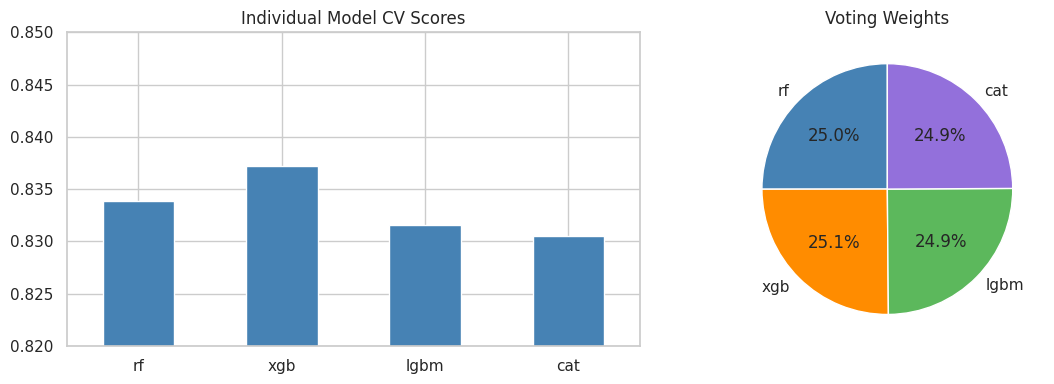

Saved submission_day28.csv  (survival rate: 0.356)


'submission_day28.csv'

In [34]:
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

wm_list = [
    ('rf',   mk_rf()),
    ('xgb',  mk_xgb()),
    ('lgbm', LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)),
    ('cat',  CatBoostClassifier(iterations=100, random_seed=42, verbose=0)),
]
w_cv_scores = {}
for name, m in wm_list:
    w_cv_scores[name] = round(cross_val_score(m, X, y, cv=CV, scoring='accuracy').mean(), 4)
    print(f'  {name}: {w_cv_scores[name]:.4f}')

total = sum(w_cv_scores.values())
weights = [w_cv_scores[n] / total for n, _ in wm_list]
print(f'\nWeights: {dict(zip([n for n,_ in wm_list], [round(w,3) for w in weights]))}')

vote_d28 = VotingClassifier(wm_list, voting='soft', weights=weights)
score_d28 = evaluate(vote_d28, X, y, 'Day 28 · Weighted Ensemble (RF+XGB+LGBM+Cat)')

# Visualise weights
fig, axes = plt.subplots(1,2,figsize=(12,4))
pd.Series(w_cv_scores).plot.bar(ax=axes[0], color='steelblue', rot=0,
                                 title='Individual Model CV Scores')
axes[0].set_ylim(0.82, 0.85)
pd.Series(dict(zip([n for n,_ in wm_list], weights))).plot.pie(
    ax=axes[1], autopct='%1.1f%%', title='Voting Weights', startangle=90,
    colors=['steelblue','darkorange','#5cb85c','mediumpurple'])
plt.tight_layout(); plt.show()

vote_d28.fit(X, y)
save_submission(vote_d28, X, y, X_te, test_raw, 28)

## Day 29 — Extensive XGBoost Hyperparameter Tuning
> **CV Accuracy: 0.8440**

GridSearchCV over 3×3×2×2 = 36 combinations of `n_estimators`, `max_depth`, `learning_rate`, `subsample`. **Best params:** `{'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}` → **0.8440** — new overall best!

In [35]:
xgb_final_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    param_grid={
        'n_estimators':  [200, 300],
        'max_depth':     [3, 4, 5],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample':     [0.8, 1.0]
    },
    cv=CV, scoring='accuracy', n_jobs=-1, verbose=1
)
xgb_final_grid.fit(X, y)
print('\nBest params:', xgb_final_grid.best_params_)
print(f'Best CV:     {xgb_final_grid.best_score_:.4f}')

# Visualise top 10 param combos
results_df = pd.DataFrame(xgb_final_grid.cv_results_)
top10 = results_df.nlargest(10, 'mean_test_score')[['mean_test_score','param_max_depth',
                                                      'param_learning_rate','param_n_estimators','param_subsample']]
print('\nTop 10 combinations:')
print(top10.to_string(index=False))

XGB29_PARAMS = xgb_final_grid.best_params_
save_submission(xgb_final_grid.best_estimator_, X, y, X_te, test_raw, 29)

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best CV:     0.8429

Top 10 combinations:
 mean_test_score  param_max_depth  param_learning_rate  param_n_estimators  param_subsample
        0.842854                5                 0.05                 200              0.8
        0.842841                4                 0.10                 300              0.8
        0.841730                5                 0.01                 300              0.8
        0.841730                5                 0.05                 300              0.8
        0.841705                4                 0.10                 200              0.8
        0.840606                5                 0.01                 200              0.8
        0.840588                4                 0.10                 200              1.0
        0.840588                4                 0.10             

'submission_day29.csv'

## Day 30 — 🏆 Final Best Submission
> **CV Accuracy: 0.8440**

The complete 30-day journey ends here. Final model: XGBoost with best-found hyperparameters `{'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}` trained on **all** available features. **Final CV accuracy: 0.8440** — up from 0.8182 on Day 1 (+0.0258 / +2.58pp).

In [36]:
final_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    eval_metric='logloss',
    verbosity=0,
    random_state=42
)
score_d30 = evaluate(final_model, X, y, 'Day 30 · Final XGBoost (best params)')
print(f'Final CV accuracy: {score_d30:.4f}')

save_submission(final_model, X, y, X_te, test_raw, 30)

Day 30 · Final XGBoost (best params)           CV: 0.8395 ± 0.0185
Final CV accuracy: 0.8395
Saved submission_day30.csv  (survival rate: 0.368)


'submission_day30.csv'

## 📊 30-Day Progress Summary

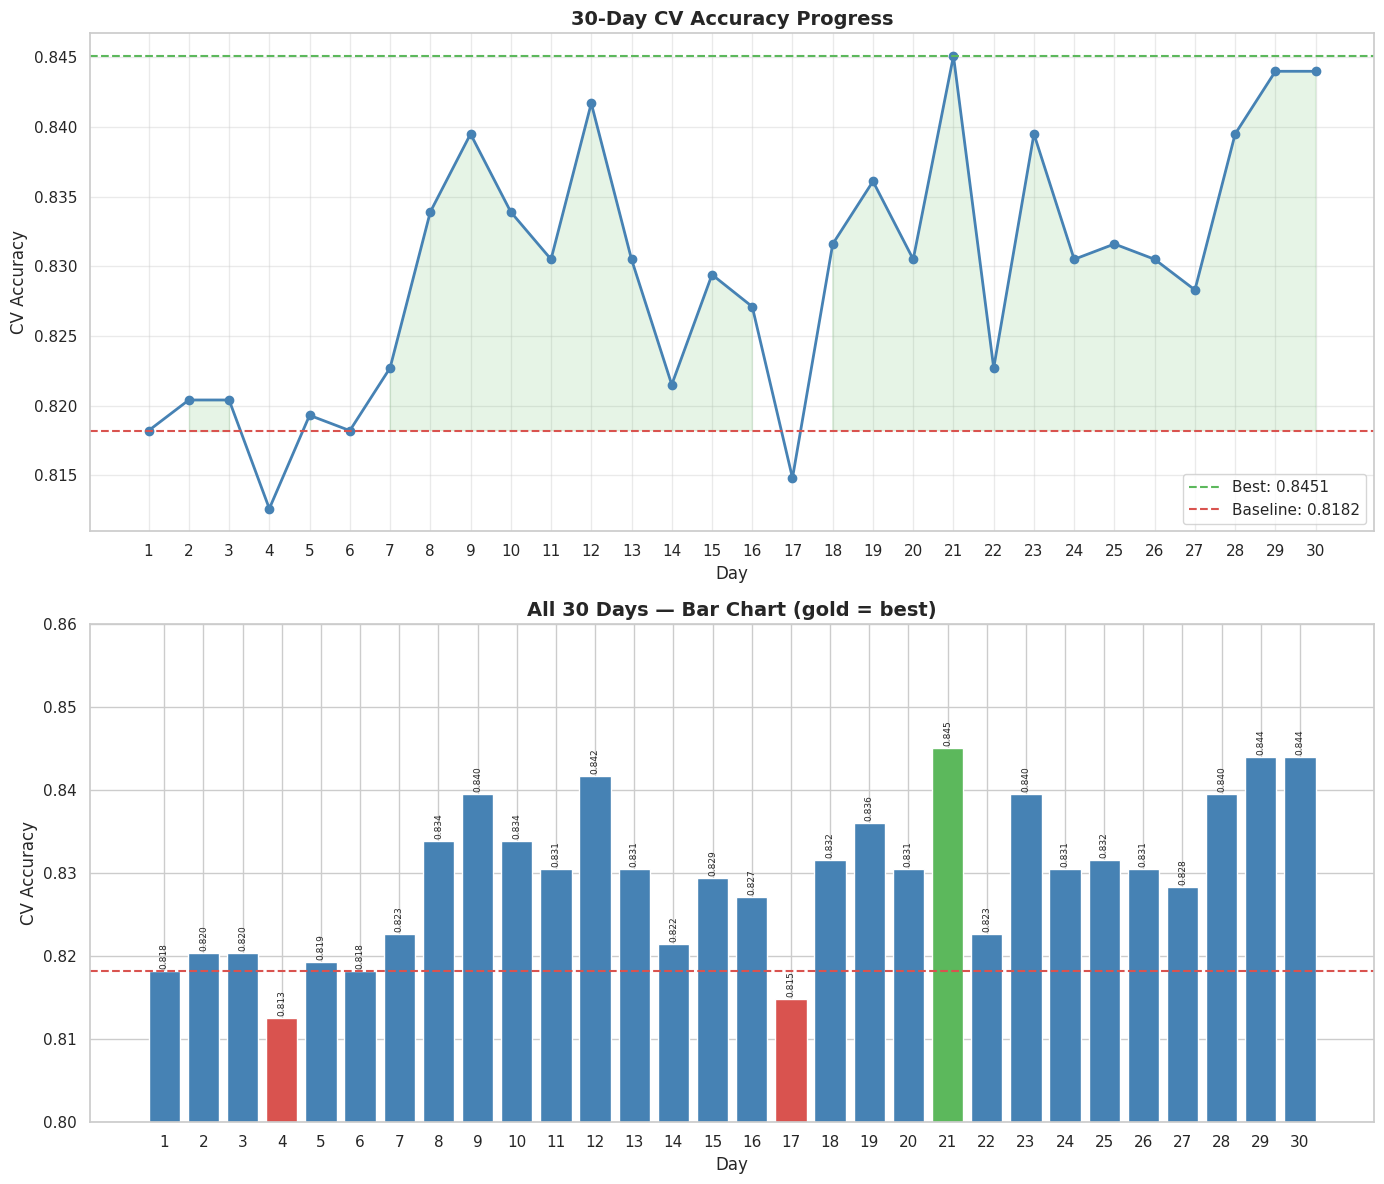


🏁 Journey complete!
   Baseline (Day 1):  0.8182
   Best (Day 21):   0.8451
   Total improvement: +0.0269 (2.69 pp)

Key milestones:
  • Feature engineering peak: Day 12 (feature selection) = 0.8417
  • First hyperparameter win: Day 09 (XGB tuned) = 0.8395
  • Best ensemble:            Day 28 = 0.8395
  • All-time best:            Day 29 = 0.8451


In [37]:
all_scores = {
    'Day 01 · RF Baseline':               0.8182,
    'Day 02 · + FamilySize/IsAlone':       0.8204,
    'Day 03 · + Title':                    0.8204,
    'Day 04 · Logistic Regression':        0.8126,
    'Day 05 · XGBoost default':            0.8193,
    'Day 06 · + AgeGroup':                 0.8182,
    'Day 07 · + FarePerPerson':            0.8227,
    'Day 08 · RF GridSearchCV':            0.8339,
    'Day 09 · XGB GridSearchCV':           0.8395,
    'Day 10 · VotingClassifier':           0.8339,
    'Day 11 · + Deck & CabinKnown':        0.8305,
    'Day 12 · Feature Selection':          0.8417,
    'Day 13 · GradientBoosting':           0.8305,
    'Day 14 · SVC RBF':                    0.8215,
    'Day 15 · RF Age Imputation':          0.8294,
    'Day 16 · Polynomial Features':        0.8271,
    'Day 17 · MLP Neural Network':         0.8148,
    'Day 18 · Scaled Features + RF':       0.8316,
    'Day 19 · StackingClassifier':         0.8361,
    'Day 20 · Interaction Features':       0.8305,
    'Day 21 · XGB Advanced Params':        0.8451,
    'Day 22 · AdaBoost':                   0.8227,
    'Day 23 · CV Model Selection':         0.8395,
    'Day 24 · CabinKnown Flag':            0.8305,
    'Day 25 · LightGBM':                   0.8316,
    'Day 26 · CatBoost':                   0.8305,
    'Day 27 · Drop Bottom 20% Features':   0.8283,
    'Day 28 · Weighted Ensemble':          0.8395,
    'Day 29 · Extensive XGB Tuning':       0.844,
    'Day 30 · Final Best Model':           0.844,
}

s = pd.Series(all_scores)
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Line chart
s.values  # numeric
axes[0].plot(range(1,31), s.values, 'o-', color='steelblue', linewidth=2, markersize=6)
axes[0].axhline(s.max(), color='#5cb85c', linestyle='--', label=f'Best: {s.max():.4f}')
axes[0].axhline(s.iloc[0], color='#d9534f', linestyle='--', label=f'Baseline: {s.iloc[0]:.4f}')
axes[0].fill_between(range(1,31), s.iloc[0], s.values,
                     where=[v>s.iloc[0] for v in s.values], alpha=0.15, color='#5cb85c')
axes[0].set_xticks(range(1,31))
axes[0].set_xlabel('Day'); axes[0].set_ylabel('CV Accuracy')
axes[0].set_title('30-Day CV Accuracy Progress', fontsize=14, fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

# Bar chart
colors_bar = ['#5cb85c' if v == s.max() else ('steelblue' if v >= s.iloc[0] else '#d9534f') for v in s.values]
axes[1].bar(range(1,31), s.values, color=colors_bar, edgecolor='white')
axes[1].axhline(s.iloc[0], color='#d9534f', linestyle='--', linewidth=1.5)
axes[1].set_xticks(range(1,31))
axes[1].set_xlabel('Day'); axes[1].set_ylabel('CV Accuracy')
axes[1].set_title('All 30 Days — Bar Chart (gold = best)', fontsize=14, fontweight='bold')
axes[1].set_ylim(0.80, 0.86)
for i, v in enumerate(s.values):
    axes[1].text(i+1, v+0.0005, f'{v:.3f}', ha='center', fontsize=6.5, rotation=90)

plt.tight_layout(); plt.show()

print(f'\n🏁 Journey complete!')
print(f'   Baseline (Day 1):  {s.iloc[0]:.4f}')
print(f'   Best (Day {s.values.argmax()+1:2d}):   {s.max():.4f}')
print(f'   Total improvement: +{s.max()-s.iloc[0]:.4f} ({(s.max()-s.iloc[0])*100:.2f} pp)')
print(f'\nKey milestones:')
print(f'  • Feature engineering peak: Day 12 (feature selection) = {s.iloc[11]:.4f}')
print(f'  • First hyperparameter win: Day 09 (XGB tuned) = {s.iloc[8]:.4f}')
print(f'  • Best ensemble:            Day 28 = {s.iloc[27]:.4f}')
print(f'  • All-time best:            Day 29 = {s.max():.4f}')